# Pandas Essentials - Basics, Data Inspection, Data Transformation, Merging, and Time-series Basics

In [3]:
import pandas as pd

In [4]:
import numpy as np

In [5]:
from io import StringIO

## Loading and Inspecting Data

In [6]:
sales_csv = '''
date,store,product,price,qty,region,customer_id
2025-01-01,Store A,Widget,20.0,2,North,1001
2025-01-02,Store B,Gadget,35.5,1,South,1002
2025-01-02,Store A,Widget,20.0,1,North,1003
2025-01-03,Store C,Thing,12.0,5,West,1004
2025-01-04,Store B,Widget,20.0,,South,1005
2025-01-05,Store A,Gadget,35.5,2,North,
2025-01-06,Store C,Thing,12.0,3,West,1006
2025-01-07,Store B,Widget,20.0,4,South,1007
'''

sales = pd.read_csv(StringIO(sales_csv), parse_dates=["date"])
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         8 non-null      datetime64[ns]
 1   store        8 non-null      object        
 2   product      8 non-null      object        
 3   price        8 non-null      float64       
 4   qty          7 non-null      float64       
 5   region       8 non-null      object        
 6   customer_id  7 non-null      float64       
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 580.0+ bytes


In [51]:
customer_csv = '''
customer_id,name,signup_date,city,active_flag
1001,Alice,2024-06-10,Pune,True
1002,Bob,2023-12-01,Chennai,True
1003,Carol,2024-01-15,Mumbai,False
1004,David,2022-09-05,Bengaluru,True
1005,Eve,2024-11-20,Hyderabad,True
1006,Frank,2023-03-03,Pune,False
1007,Grace,2025-01-02,Mumbai,True
'''

customer = pd.read_csv(StringIO(customer_csv), parse_dates=["signup_date"])

In [ ]:

sales.describe(include='all')

,date,store,product,price,qty,region,customer_id
count,8,8,8,8.000000,7.000000,8,7.000000
unique,NaN,3,3,NaN,NaN,3,NaN
top,NaN,Store A,Widget,NaN,NaN,North,NaN
freq,NaN,3,4,NaN,NaN,3,NaN
mean,2025-01-03 18:00:00,NaN,NaN,21.875000,2.571429,NaN,1004.000000
min,2025-01-01 00:00:00,NaN,NaN,12.000000,1.000000,NaN,1001.000000
25%,2025-01-02 00:00:00,NaN,NaN,18.000000,1.500000,NaN,1002.500000
50%,2025-01-03 12:00:00,NaN,NaN,20.000000,2.000000,NaN,1004.000000
75%,2025-01-05 06:00:00,NaN,NaN,23.875000,3.500000,NaN,1005.500000
max,2025-01-07 00:00:00,NaN,NaN,35.500000,5.000000,NaN,1007.000000


In [52]:
customer.info()
customer.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  7 non-null      int64         
 1   name         7 non-null      object        
 2   signup_date  7 non-null      datetime64[ns]
 3   city         7 non-null      object        
 4   active_flag  7 non-null      bool          
dtypes: bool(1), datetime64[ns](1), int64(1), object(2)
memory usage: 363.0+ bytes


,customer_id,name,signup_date,city,active_flag
0,1001,Alice,2024-06-10,Pune,True
1,1002,Bob,2023-12-01,Chennai,True
2,1003,Carol,2024-01-15,Mumbai,False
3,1004,David,2022-09-05,Bengaluru,True
4,1005,Eve,2024-11-20,Hyderabad,True


In [12]:
sales.head()

,date,store,product,price,qty,region,customer_id
0,2025-01-01,Store A,Widget,20.0,2.0,North,1001.0
1,2025-01-02,Store B,Gadget,35.5,1.0,South,1002.0
2,2025-01-02,Store A,Widget,20.0,1.0,North,1003.0
3,2025-01-03,Store C,Thing,12.0,5.0,West,1004.0
4,2025-01-04,Store B,Widget,20.0,NaN,South,1005.0


In [15]:
sales.isna().sum()

date           0
store          0
product        0
price          0
qty            1
region         0
customer_id    1
dtype: int64

In [17]:
sales.sample(3, random_state=42)

,date,store,product,price,qty,region,customer_id
1,2025-01-02,Store B,Gadget,35.5,1.0,South,1002.0
5,2025-01-05,Store A,Gadget,35.5,2.0,North,NaN
0,2025-01-01,Store A,Widget,20.0,2.0,North,1001.0


In [18]:
sales["product"].value_counts()

product
Widget    4
Gadget    2
Thing     2
Name: count, dtype: int64

In [54]:
# Derived column
sales['revenue'] = sales['price'] * sales['qty']

sales

,date,store,product,price,qty,region,customer_id,revenue
0,2025-01-01,Store A,Widget,20.0,2.0,North,1001.0,40.0
1,2025-01-02,Store B,Gadget,35.5,1.0,South,1002.0,35.5
2,2025-01-02,Store A,Widget,20.0,1.0,North,1003.0,20.0
3,2025-01-03,Store C,Thing,12.0,5.0,West,1004.0,60.0
4,2025-01-04,Store B,Widget,20.0,NaN,South,1005.0,NaN
5,2025-01-05,Store A,Gadget,35.5,2.0,North,NaN,71.0
6,2025-01-06,Store C,Thing,12.0,3.0,West,1006.0,36.0
7,2025-01-07,Store B,Widget,20.0,4.0,South,1007.0,80.0


## Indexing and Selection using loc/iloc 

In [55]:
sales.loc[0:, ['date','store','product']]

,date,store,product
0,2025-01-01,Store A,Widget
1,2025-01-02,Store B,Gadget
2,2025-01-02,Store A,Widget
3,2025-01-03,Store C,Thing
4,2025-01-04,Store B,Widget
5,2025-01-05,Store A,Gadget
6,2025-01-06,Store C,Thing
7,2025-01-07,Store B,Widget


In [56]:
sales.loc[-1:, ['date','store','product']]

,date,store,product
0,2025-01-01,Store A,Widget
1,2025-01-02,Store B,Gadget
2,2025-01-02,Store A,Widget
3,2025-01-03,Store C,Thing
4,2025-01-04,Store B,Widget
5,2025-01-05,Store A,Gadget
6,2025-01-06,Store C,Thing
7,2025-01-07,Store B,Widget


In [57]:
sales.loc[0:2, ['date','store','product']]

,date,store,product
0,2025-01-01,Store A,Widget
1,2025-01-02,Store B,Gadget
2,2025-01-02,Store A,Widget


In [58]:
# date,store,product,price,qty,region,customer_id
sales.iloc[1:4, 0:4]

,date,store,product,price
1,2025-01-02,Store B,Gadget,35.5
2,2025-01-02,Store A,Widget,20.0
3,2025-01-03,Store C,Thing,12.0


In [59]:
# Boolean selection
sales[sales['region'] == 'North']

,date,store,product,price,qty,region,customer_id,revenue
0,2025-01-01,Store A,Widget,20.0,2.0,North,1001.0,40.0
2,2025-01-02,Store A,Widget,20.0,1.0,North,1003.0,20.0
5,2025-01-05,Store A,Gadget,35.5,2.0,North,NaN,71.0


In [60]:
sales[sales['qty'] >= 3]

,date,store,product,price,qty,region,customer_id,revenue
3,2025-01-03,Store C,Thing,12.0,5.0,West,1004.0,60.0
6,2025-01-06,Store C,Thing,12.0,3.0,West,1006.0,36.0
7,2025-01-07,Store B,Widget,20.0,4.0,South,1007.0,80.0


In [61]:
# Use isin to multi-select from a list
sales[sales['product'].isin(['Widget','Thing']) & (sales['qty'] > 1)]

,date,store,product,price,qty,region,customer_id,revenue
0,2025-01-01,Store A,Widget,20.0,2.0,North,1001.0,40.0
3,2025-01-03,Store C,Thing,12.0,5.0,West,1004.0,60.0
6,2025-01-06,Store C,Thing,12.0,3.0,West,1006.0,36.0
7,2025-01-07,Store B,Widget,20.0,4.0,South,1007.0,80.0


## Data Cleaning and Transformation

In [62]:
# Count the number of column values marked as NA
sales.isna().sum()

date           0
store          0
product        0
price          0
qty            1
region         0
customer_id    1
revenue        1
dtype: int64

In [63]:
# Create a copy of sales data to work upon
sales_filled = sales.copy()

In [64]:
sales_filled["qty"].fillna(1).astype(int)

# Recompute revenue
sales_filled['revenue'] = sales_filled['price'] * sales_filled['qty']

In [65]:
# Replace region codes
sales_filled['region'] = sales_filled['region'].replace({'North':'N','South':'S','West':'W'})

In [66]:
# String method
sales_filled['product_lower'] = sales_filled['product'].str.lower()

In [67]:
sales_filled.head()

,date,store,product,price,qty,region,customer_id,revenue,product_lower
0,2025-01-01,Store A,Widget,20.0,2.0,N,1001.0,40.0,widget
1,2025-01-02,Store B,Gadget,35.5,1.0,S,1002.0,35.5,gadget
2,2025-01-02,Store A,Widget,20.0,1.0,N,1003.0,20.0,widget
3,2025-01-03,Store C,Thing,12.0,5.0,W,1004.0,60.0,thing
4,2025-01-04,Store B,Widget,20.0,NaN,S,1005.0,NaN,widget


## GroupBy Aggregation & Pivoting

In [49]:
sales_filled.groupby("product").agg(
    total_qty= ('qty', 'sum')
)

,total_qty
product,
Gadget,3.0
Thing,8.0
Widget,7.0


In [50]:
sales_filled.groupby("product").agg(
    total_qty = ('qty', 'sum'),
    avg_price = ("price", "mean")
)

,total_qty,avg_price
product,,
Gadget,3.0,35.5
Thing,8.0,12.0
Widget,7.0,20.0


In [68]:
sales_filled.groupby("product").agg(
    total_qty = ("qty", "sum"),
    avg_price = ("price", "mean"),
    total_revenue = ("revenue", "sum")
)

,total_qty,avg_price,total_revenue
product,,,
Gadget,3.0,35.5,106.5
Thing,8.0,12.0,96.0
Widget,7.0,20.0,140.0


In [1]:
s_df = sales_filled.groupby("product").agg(
    total_qty = ("qty", "sum"),
    avg_price = ("price", "mean"),
    total_revenue = ("revenue", "sum")
)
s_df

NameError: name 'sales_filled' is not defined

## Merging and Time-Series Basics

In [70]:
sales_enriched = sales_filled.merge(customer, how="left", on="customer_id")

sales_enriched

,date,store,product,price,qty,region,customer_id,revenue,product_lower,name,signup_date,city,active_flag
0,2025-01-01,Store A,Widget,20.0,2.0,N,1001.0,40.0,widget,Alice,2024-06-10,Pune,True
1,2025-01-02,Store B,Gadget,35.5,1.0,S,1002.0,35.5,gadget,Bob,2023-12-01,Chennai,True
2,2025-01-02,Store A,Widget,20.0,1.0,N,1003.0,20.0,widget,Carol,2024-01-15,Mumbai,False
3,2025-01-03,Store C,Thing,12.0,5.0,W,1004.0,60.0,thing,David,2022-09-05,Bengaluru,True
4,2025-01-04,Store B,Widget,20.0,NaN,S,1005.0,NaN,widget,Eve,2024-11-20,Hyderabad,True
5,2025-01-05,Store A,Gadget,35.5,2.0,N,NaN,71.0,gadget,NaN,NaT,NaN,NaN
6,2025-01-06,Store C,Thing,12.0,3.0,W,1006.0,36.0,thing,Frank,2023-03-03,Pune,False
7,2025-01-07,Store B,Widget,20.0,4.0,S,1007.0,80.0,widget,Grace,2025-01-02,Mumbai,True


In [71]:
sales_enriched_2 = sales_filled.merge(customer, how="right", on="customer_id")

sales_enriched_2

,date,store,product,price,qty,region,customer_id,revenue,product_lower,name,signup_date,city,active_flag
0,2025-01-01,Store A,Widget,20.0,2.0,N,1001.0,40.0,widget,Alice,2024-06-10,Pune,True
1,2025-01-02,Store B,Gadget,35.5,1.0,S,1002.0,35.5,gadget,Bob,2023-12-01,Chennai,True
2,2025-01-02,Store A,Widget,20.0,1.0,N,1003.0,20.0,widget,Carol,2024-01-15,Mumbai,False
3,2025-01-03,Store C,Thing,12.0,5.0,W,1004.0,60.0,thing,David,2022-09-05,Bengaluru,True
4,2025-01-04,Store B,Widget,20.0,NaN,S,1005.0,NaN,widget,Eve,2024-11-20,Hyderabad,True
5,2025-01-06,Store C,Thing,12.0,3.0,W,1006.0,36.0,thing,Frank,2023-03-03,Pune,False
6,2025-01-07,Store B,Widget,20.0,4.0,S,1007.0,80.0,widget,Grace,2025-01-02,Mumbai,True


In [72]:
# Time-Series: set date index
sales_enriched["date"] = pd.to_datetime(sales_enriched["date"])
sales_ts = sales_enriched.set_index("date").sort_index()

sales_ts

,store,product,price,qty,region,customer_id,revenue,product_lower,name,signup_date,city,active_flag
date,,,,,,,,,,,,
2025-01-01,Store A,Widget,20.0,2.0,N,1001.0,40.0,widget,Alice,2024-06-10,Pune,True
2025-01-02,Store B,Gadget,35.5,1.0,S,1002.0,35.5,gadget,Bob,2023-12-01,Chennai,True
2025-01-02,Store A,Widget,20.0,1.0,N,1003.0,20.0,widget,Carol,2024-01-15,Mumbai,False
2025-01-03,Store C,Thing,12.0,5.0,W,1004.0,60.0,thing,David,2022-09-05,Bengaluru,True
2025-01-04,Store B,Widget,20.0,NaN,S,1005.0,NaN,widget,Eve,2024-11-20,Hyderabad,True
2025-01-05,Store A,Gadget,35.5,2.0,N,NaN,71.0,gadget,NaN,NaT,NaN,NaN
2025-01-06,Store C,Thing,12.0,3.0,W,1006.0,36.0,thing,Frank,2023-03-03,Pune,False
2025-01-07,Store B,Widget,20.0,4.0,S,1007.0,80.0,widget,Grace,2025-01-02,Mumbai,True


In [73]:
daily_rev = sales_ts["revenue"].resample('D').sum().fillna(0)

daily_rev

date
2025-01-01    40.0
2025-01-02    55.5
2025-01-03    60.0
2025-01-04     0.0
2025-01-05    71.0
2025-01-06    36.0
2025-01-07    80.0
Freq: D, Name: revenue, dtype: float64

In [74]:
rolling_3 = daily_rev.rolling(window= 3, min_periods=1).mean()

rolling_3

date
2025-01-01    40.000000
2025-01-02    47.750000
2025-01-03    51.833333
2025-01-04    38.500000
2025-01-05    43.666667
2025-01-06    35.666667
2025-01-07    62.333333
Freq: D, Name: revenue, dtype: float64

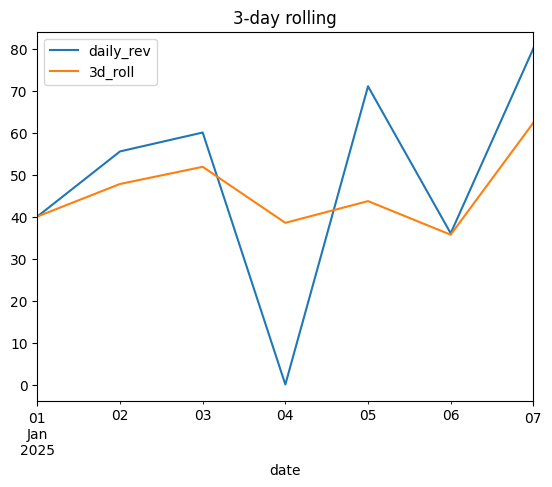

In [76]:
import matplotlib.pyplot as plt

plt.figure()
daily_rev.plot(title='Daily Revenue')
rolling_3.plot(title='3-day rolling')

plt.legend(['daily_rev','3d_roll'])
plt.show()

In [77]:
sales_enriched.head()

,date,store,product,price,qty,region,customer_id,revenue,product_lower,name,signup_date,city,active_flag
0,2025-01-01,Store A,Widget,20.0,2.0,N,1001.0,40.0,widget,Alice,2024-06-10,Pune,True
1,2025-01-02,Store B,Gadget,35.5,1.0,S,1002.0,35.5,gadget,Bob,2023-12-01,Chennai,True
2,2025-01-02,Store A,Widget,20.0,1.0,N,1003.0,20.0,widget,Carol,2024-01-15,Mumbai,False
3,2025-01-03,Store C,Thing,12.0,5.0,W,1004.0,60.0,thing,David,2022-09-05,Bengaluru,True
4,2025-01-04,Store B,Widget,20.0,NaN,S,1005.0,NaN,widget,Eve,2024-11-20,Hyderabad,True


## Exercise Section 

Q1. Top Products by revenue: Find top 2 Products by revenue

In [91]:
products = sales_enriched.groupby("product").agg(
    total_revenue = ("revenue", "sum")
)

products.nlargest(2, "total_revenue")

,total_revenue
product,
Widget,140.0
Gadget,106.5


In [89]:
products = sales_enriched.groupby("product")["revenue"].sum().nlargest(2)

products

product
Widget    140.0
Gadget    106.5
Name: revenue, dtype: float64

Q2. Store Averages: Compute average basket size (qty) and average revenue per transaction per store.

In [99]:
stores = sales_enriched.groupby("store").agg(
    qty = ("qty", "sum"),
    avg_qty = ("qty", "mean"),
    revenue = ("revenue", "sum"),
    avg_rev = ("revenue", "mean")
)

stores["average_revenue_per_transaction"] = stores["revenue"] / stores["qty"]

stores

,qty,avg_qty,revenue,avg_rev,average_revenue_per_transaction
store,,,,,
Store A,5.0,1.666667,131.0,43.666667,26.2
Store B,5.0,2.500000,115.5,57.750000,23.1
Store C,8.0,4.000000,96.0,48.000000,12.0


Q3. Missing Customers: Identify customers who made a purchase but are missing from customer.csv

In [100]:
customer

,customer_id,name,signup_date,city,active_flag
0,1001,Alice,2024-06-10,Pune,True
1,1002,Bob,2023-12-01,Chennai,True
2,1003,Carol,2024-01-15,Mumbai,False
3,1004,David,2022-09-05,Bengaluru,True
4,1005,Eve,2024-11-20,Hyderabad,True
5,1006,Frank,2023-03-03,Pune,False
6,1007,Grace,2025-01-02,Mumbai,True


In [105]:
missing = sales_filled[sales_filled["customer_id"].isna()]

missing

,date,store,product,price,qty,region,customer_id,revenue,product_lower
5,2025-01-05,Store A,Gadget,35.5,2.0,N,NaN,71.0,gadget


In [106]:
missing = sales_enriched[sales_enriched["name"].isna()]
missing

,date,store,product,price,qty,region,customer_id,revenue,product_lower,name,signup_date,city,active_flag
5,2025-01-05,Store A,Gadget,35.5,2.0,N,NaN,71.0,gadget,NaN,NaT,NaN,NaN


Q4. Pivot Table: Create a Pivot table - showing qty sold by products (rows) and region (columns)

In [109]:
pd.pivot_table(sales_filled, values="qty", index="product", columns="region", aggfunc="sum", fill_value=1)

region,N,S,W
product,,,
Gadget,2.0,1.0,1.0
Thing,1.0,1.0,8.0
Widget,3.0,4.0,1.0


Q5. Weekly Resample: Resample revenue to weekly and find the week with highest revenue 

In [112]:
weekly_rev = sales_ts["revenue"].resample('W').sum().nlargest(1)
weekly_rev

date
2025-01-05    226.5
Freq: W-SUN, Name: revenue, dtype: float64

Q6. Churn: Join sales with customers and compute churn; Customers who signedup before 2024-01-01 but have not made any purchase in 24

In [154]:
# Sales record such that one of the customer 'Bob' who signed up before 2024-01-01 but made no purchase in 2025
sales_csv = '''
date,store,product,price,qty,region,customer_id
2025-01-01,Store A,Widget,20.0,2,North,1001
2025-01-02,Store B,Gadget,35.5,1,South,1004
2025-01-02,Store A,Widget,20.0,1,North,1003
2025-01-03,Store C,Thing,12.0,5,West,1004
2025-01-04,Store B,Widget,20.0,,South,1005
2025-01-05,Store A,Gadget,35.5,2,North,
2025-01-06,Store C,Thing,12.0,3,West,1006
2025-01-07,Store B,Widget,20.0,4,South,1007
'''
sales_filled_c = pd.read_csv(StringIO(sales_csv), parse_dates=["date"]).fillna(1)

# Figure out all customers who signed up before the given date
signedup = customer[customer["signup_date"]<=pd.to_datetime("2024-01-02")]
print(signedup)

# Figure out all signedup customers who do not have a record under sales
signedup[~signedup['customer_id'].isin(sales_filled_c["customer_id"])]

   customer_id   name signup_date       city  active_flag
1         1002    Bob  2023-12-01    Chennai         True
3         1004  David  2022-09-05  Bengaluru         True
5         1006  Frank  2023-03-03       Pune        False


,customer_id,name,signup_date,city,active_flag
1,1002,Bob,2023-12-01,Chennai,True


Q7. Feature & Max-Transactions: Create avg_price_per_unit per transaction and find transactions with highest value

In [160]:
sales_filled["avg_price_per_unit"] = sales_filled["revenue"] / sales_filled["qty"]
sales_filled.loc[sales_filled["avg_price_per_unit"].idxmax()]

date                  2025-01-02 00:00:00
store                             Store B
product                            Gadget
price                                35.5
qty                                   1.0
region                                  S
customer_id                        1002.0
revenue                              35.5
product_lower                      gadget
avg_price_per_unit                   35.5
Name: 1, dtype: object

Q8. Normalize Product Names: Build a function to normalize product names (strip, lower, remove punctuation) and apply it; compare counts before and after

In [164]:
import string

def normalize(s: str) -> str:
    if pd.isna(s):
        return s
    s = s.lower().strip()
    s = s.translate(s.maketrans('', '', string.punctuation))
    return s
sales_enriched["product_norm"] = sales_enriched["product"].apply(normalize)
sales_enriched.loc[0:, ["product", "product_norm"]] 

,product,product_norm
0,Widget,widget
1,Gadget,gadget
2,Widget,widget
3,Thing,thing
4,Widget,widget
5,Gadget,gadget
6,Thing,thing
7,Widget,widget


In [168]:
sales_enriched["product_norm_2"] = sales_enriched["product"].apply(lambda x: x.lower().strip().translate(x.maketrans('','', string.punctuation)))
sales_enriched.loc[0:,["product", "product_norm_2"]]

,product,product_norm_2
0,Widget,widget
1,Gadget,gadget
2,Widget,widget
3,Thing,thing
4,Widget,widget
5,Gadget,gadget
6,Thing,thing
7,Widget,widget
